# UNet-Lite — Human Segmentation (COCO 2017)

Notebook điều phối **mỏng**: toàn bộ logic nằm trong package `src/`. Notebook chỉ gọi API.

**Các cải tiến mới:**
- ✅ AttentionBottleneck (Linear Self Attention ở bottleneck)
- ✅ PersonStampPool (Copy-Paste không load I/O)
- ✅ Profiling tools (DataLoader throughput + model FPS)
- ✅ TensorBoard logging
- ✅ `--subset` flag (debug nhanh)
- ✅ 20 unit tests

> Chạy từ **thư mục gốc dự án** để import được `cv_nets`.

In [1]:
import os, sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from src import (
    Config, build_model, build_dataloaders, build_loss, fit, load_checkpoint,
)
from src.model import count_parameters
from src import visualize as viz
import torch

print('CUDA:', torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')

CUDA: True NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
cfg = Config()
print('Thiết bị:', cfg.device, '| Ảnh:', cfg.image_size)
print('Batch:', cfg.batch_size, '| Accum:', cfg.accumulation_steps,
      '| Loss:', cfg.loss_name, '| Epochs:', cfg.epochs, '| LR:', cfg.lr)
print('Attention:', 'BẬT' if cfg.use_attention else 'TẮT')

# Bỏ comment để bật Attention:
cfg.use_attention = True

Thiết bị: cuda | Ảnh: (320, 320)
Batch: 16 | Accum: 16 | Loss: focal_dice | Epochs: 30 | LR: 0.001
Attention: TẮT


In [3]:
train_loader, val_loader = build_dataloaders(cfg)
print(f'Train: {len(train_loader.dataset)} ảnh | Val: {len(val_loader.dataset)} ảnh')

loading annotations into memory...
Done (t=10.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.31s)
creating index...
index created!
PersonStampPool: 1112 stamps sẵn sàng
Train: 64115 ảnh | Val: 2693 ảnh


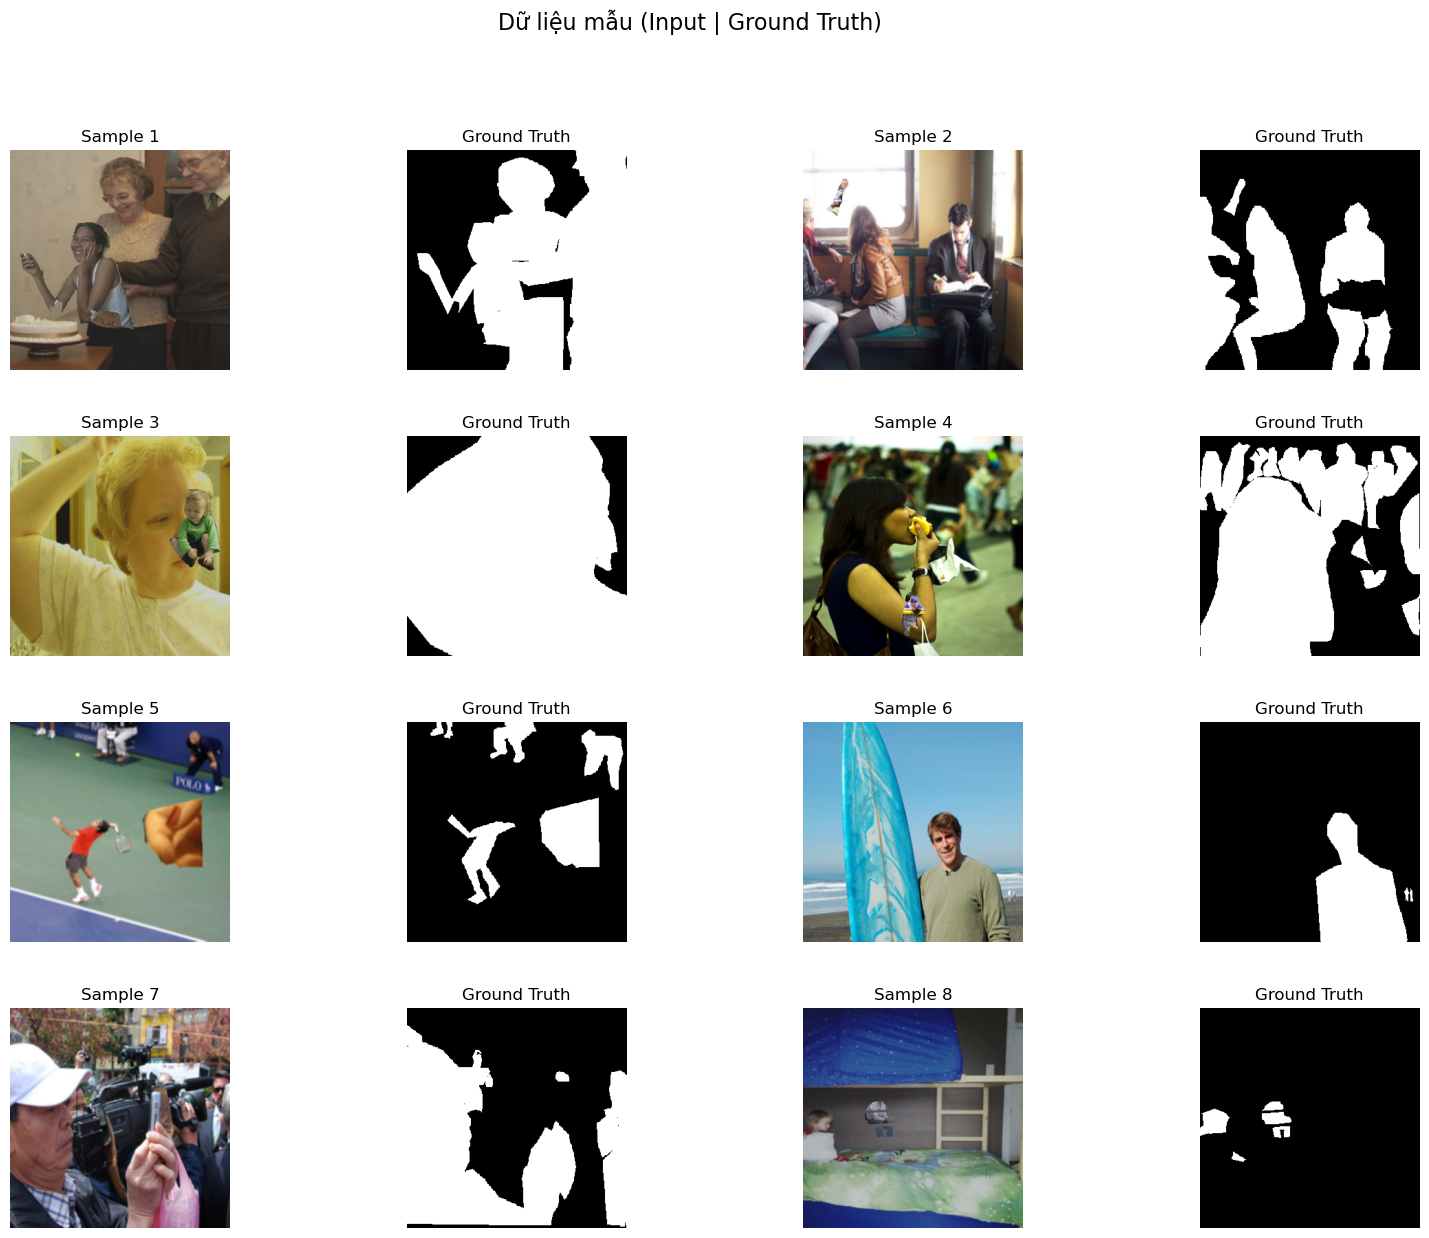

In [4]:
viz.show_batch(train_loader, num_samples=8)

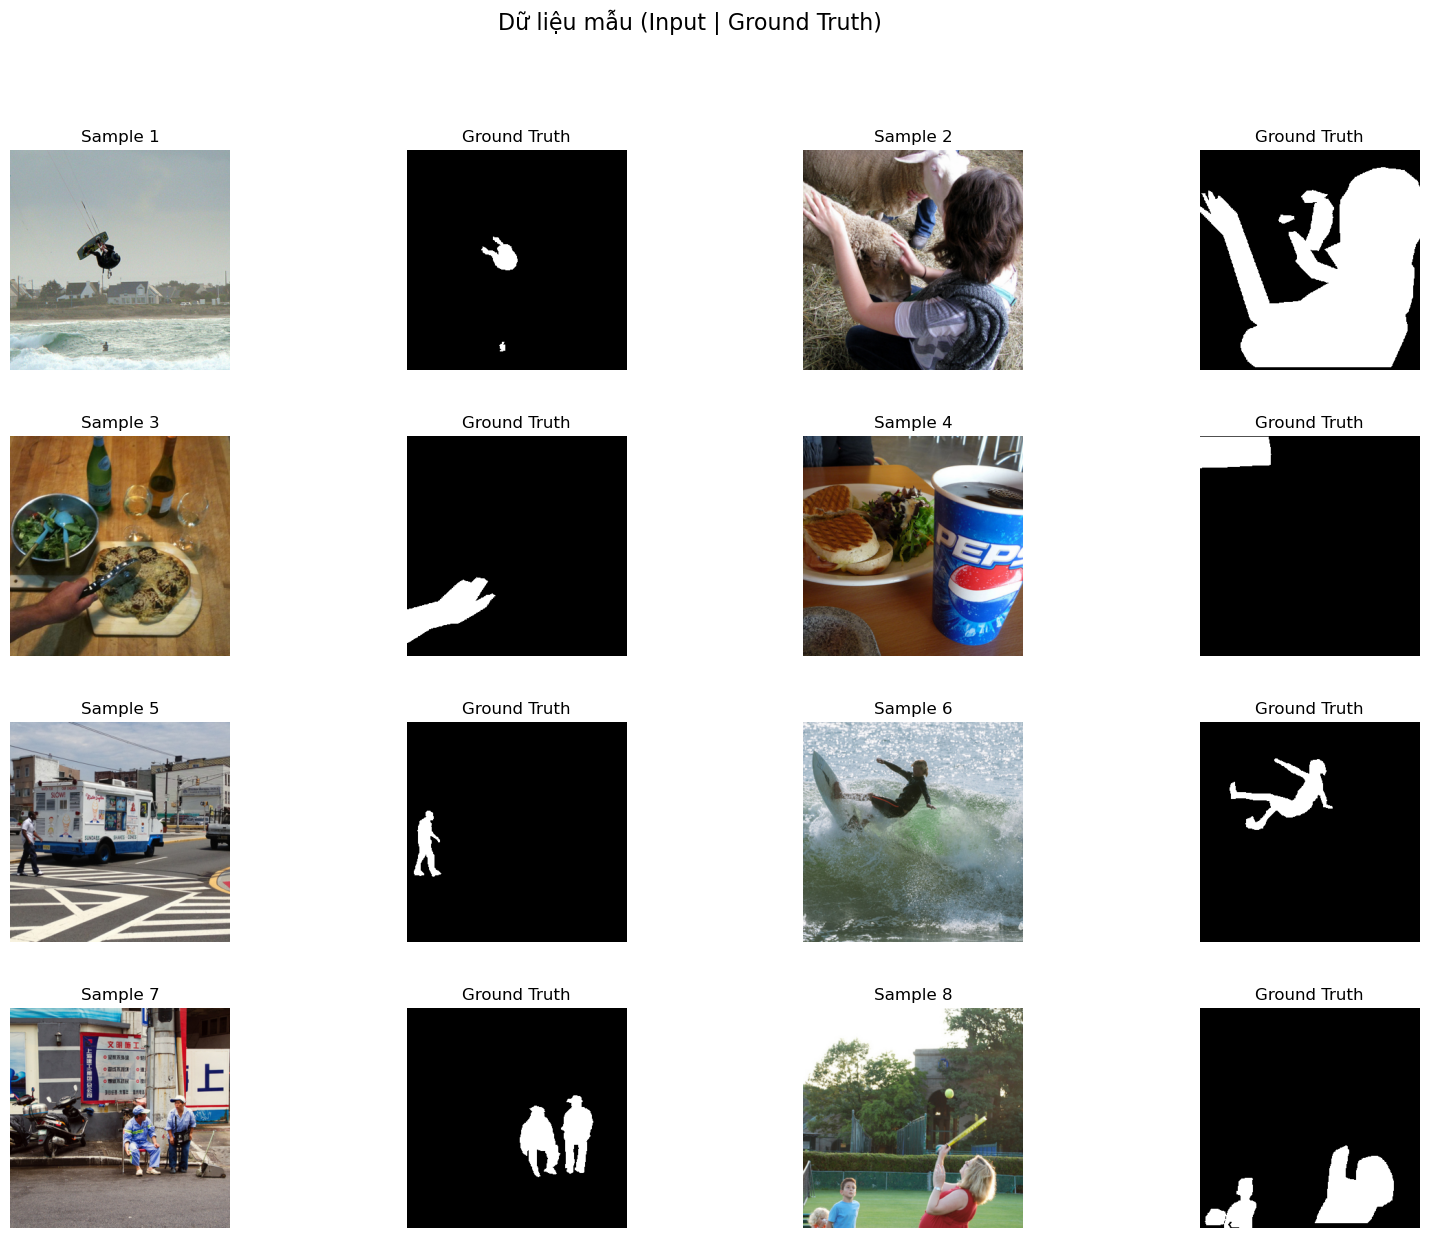

In [5]:
viz.show_batch(val_loader, num_samples=8)

In [6]:
model = build_model(cfg)
print(f'Tham số: {count_parameters(model):,}')

Tham số: 1,934,280


In [7]:
from src.profiler import benchmark_dataloader, benchmark_model_forward
print('=== DataLoader ===')
for k, v in benchmark_dataloader(train_loader, 20).items():
    print(f'  {k}: {v:.2f}')
print('\n=== Model Forward ===')
for k, v in benchmark_model_forward(model.to(cfg.device), (1,3,*cfg.image_size)).items():
    print(f'  {k}: {v:.2f}')

=== DataLoader ===
  avg_batch_time_ms: 57.62
  images_per_sec: 277.70
  avg_batch_size: 16.00
  num_batches: 20.00

=== Model Forward ===
  avg_forward_ms: 9.04
  fps: 110.66
  num_iter: 50.00


In [ ]:
criterion = build_loss(cfg)
history = fit(model, train_loader, val_loader, criterion, cfg)
# Train tiếp: fit(..., resume=cfg.last_ckpt)

Epoch 1/30 [Train]: 100%|██████████| 4007/4007 [08:49<00:00,  7.56batch/s, loss=0.3090]


-> Epoch 1 | Train 0.3105 | Val 0.2939 | IoU 0.4104 | Dice 0.5248 | LR 1.00e-03
   ✓ Lưu mô hình tốt nhất: ./models/unet_base/best_unet_base.pth


Epoch 2/30 [Train]: 100%|██████████| 4007/4007 [08:33<00:00,  7.81batch/s, loss=0.3435]


-> Epoch 2 | Train nan | Val nan | IoU 0.0214 | Dice 0.0214 | LR 9.97e-04


Epoch 3/30 [Train]: 100%|██████████| 4007/4007 [08:28<00:00,  7.88batch/s, loss=0.2871]


-> Epoch 3 | Train nan | Val nan | IoU 0.0214 | Dice 0.0214 | LR 9.89e-04


Epoch 4/30 [Train]:   1%|▏         | 60/4007 [00:08<08:15,  7.97batch/s, loss=0.3209]

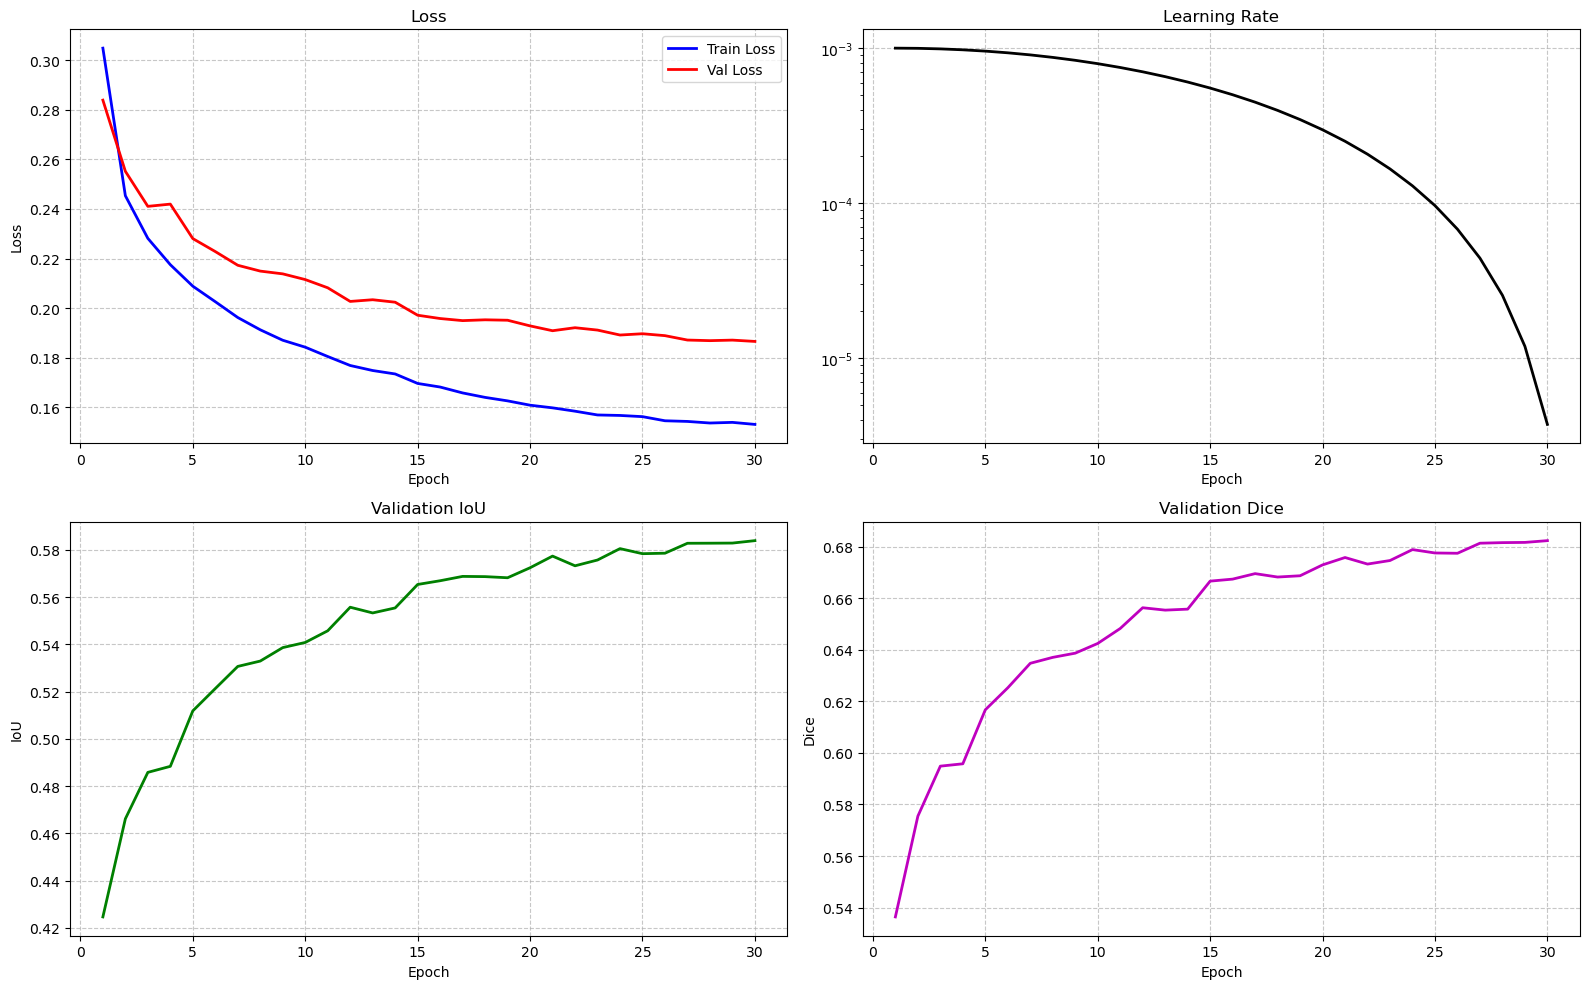

In [ ]:
viz.plot_history(history)

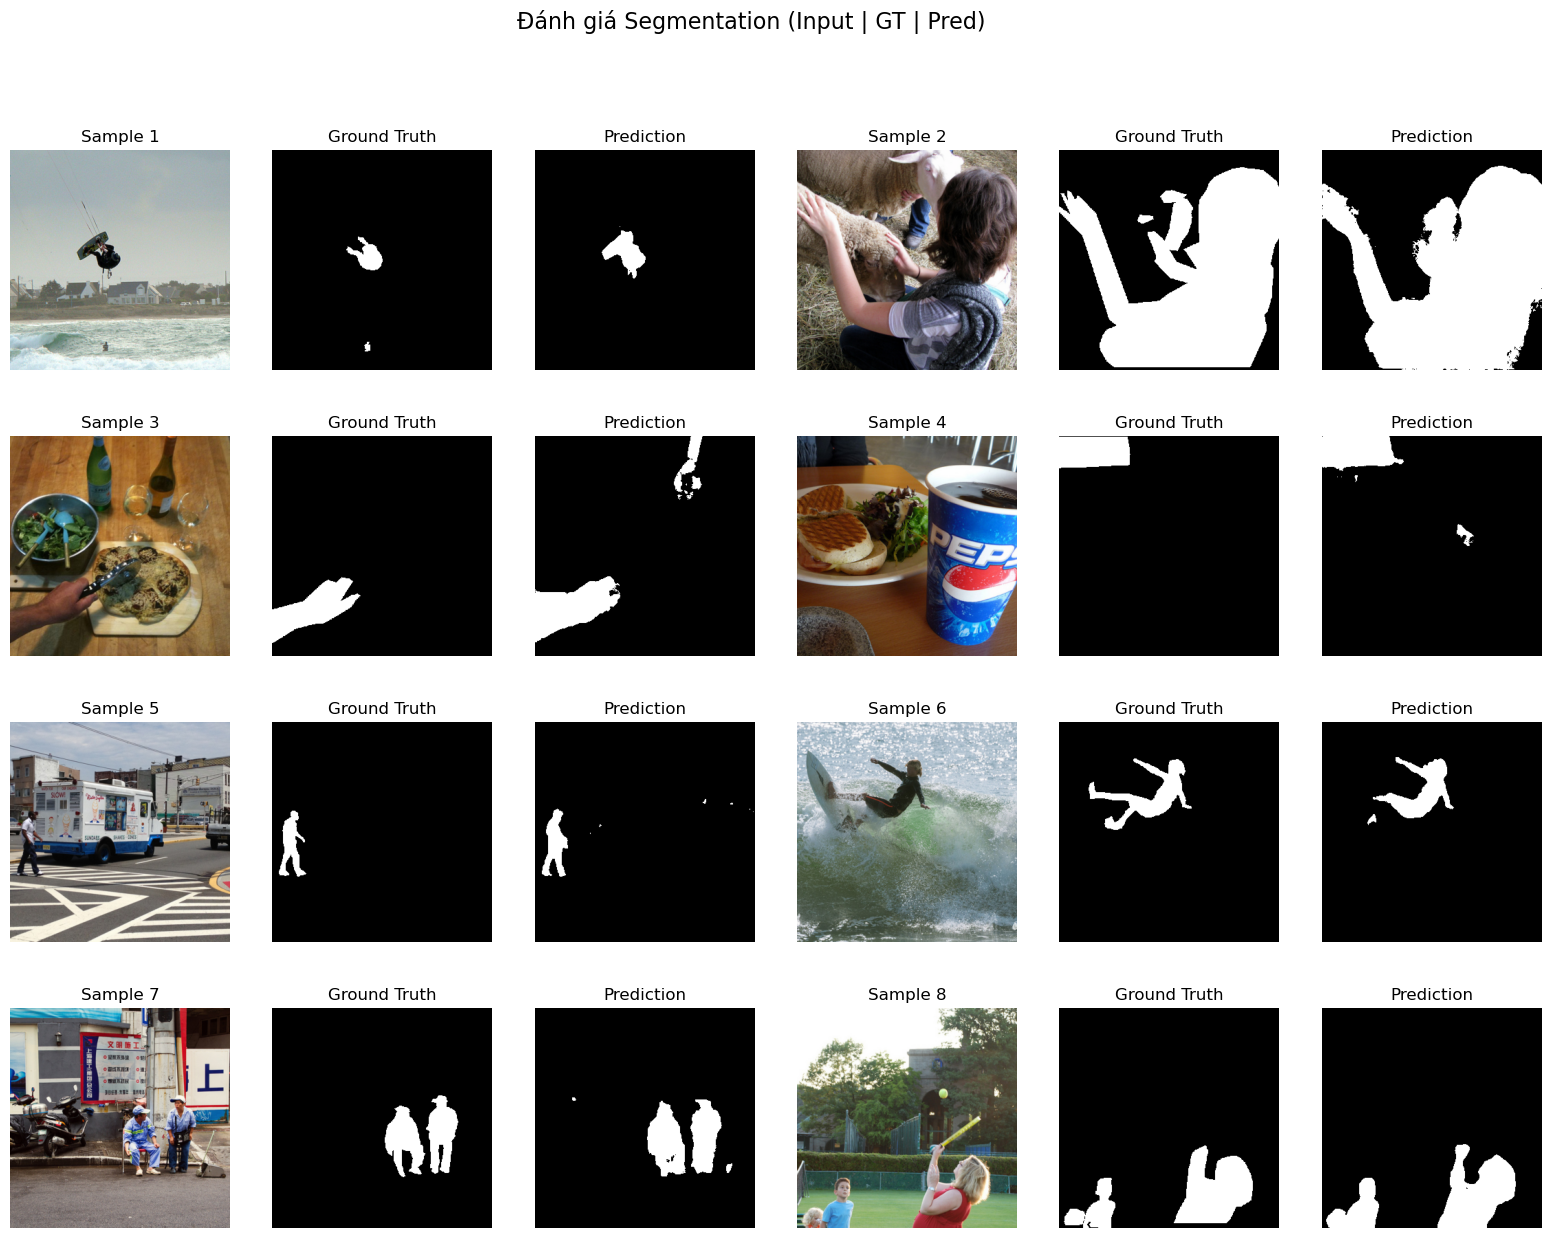

In [ ]:
load_checkpoint(cfg.best_ckpt, model.to(cfg.device), map_location=cfg.device)
viz.show_predictions(model, val_loader, cfg, num_samples=8)

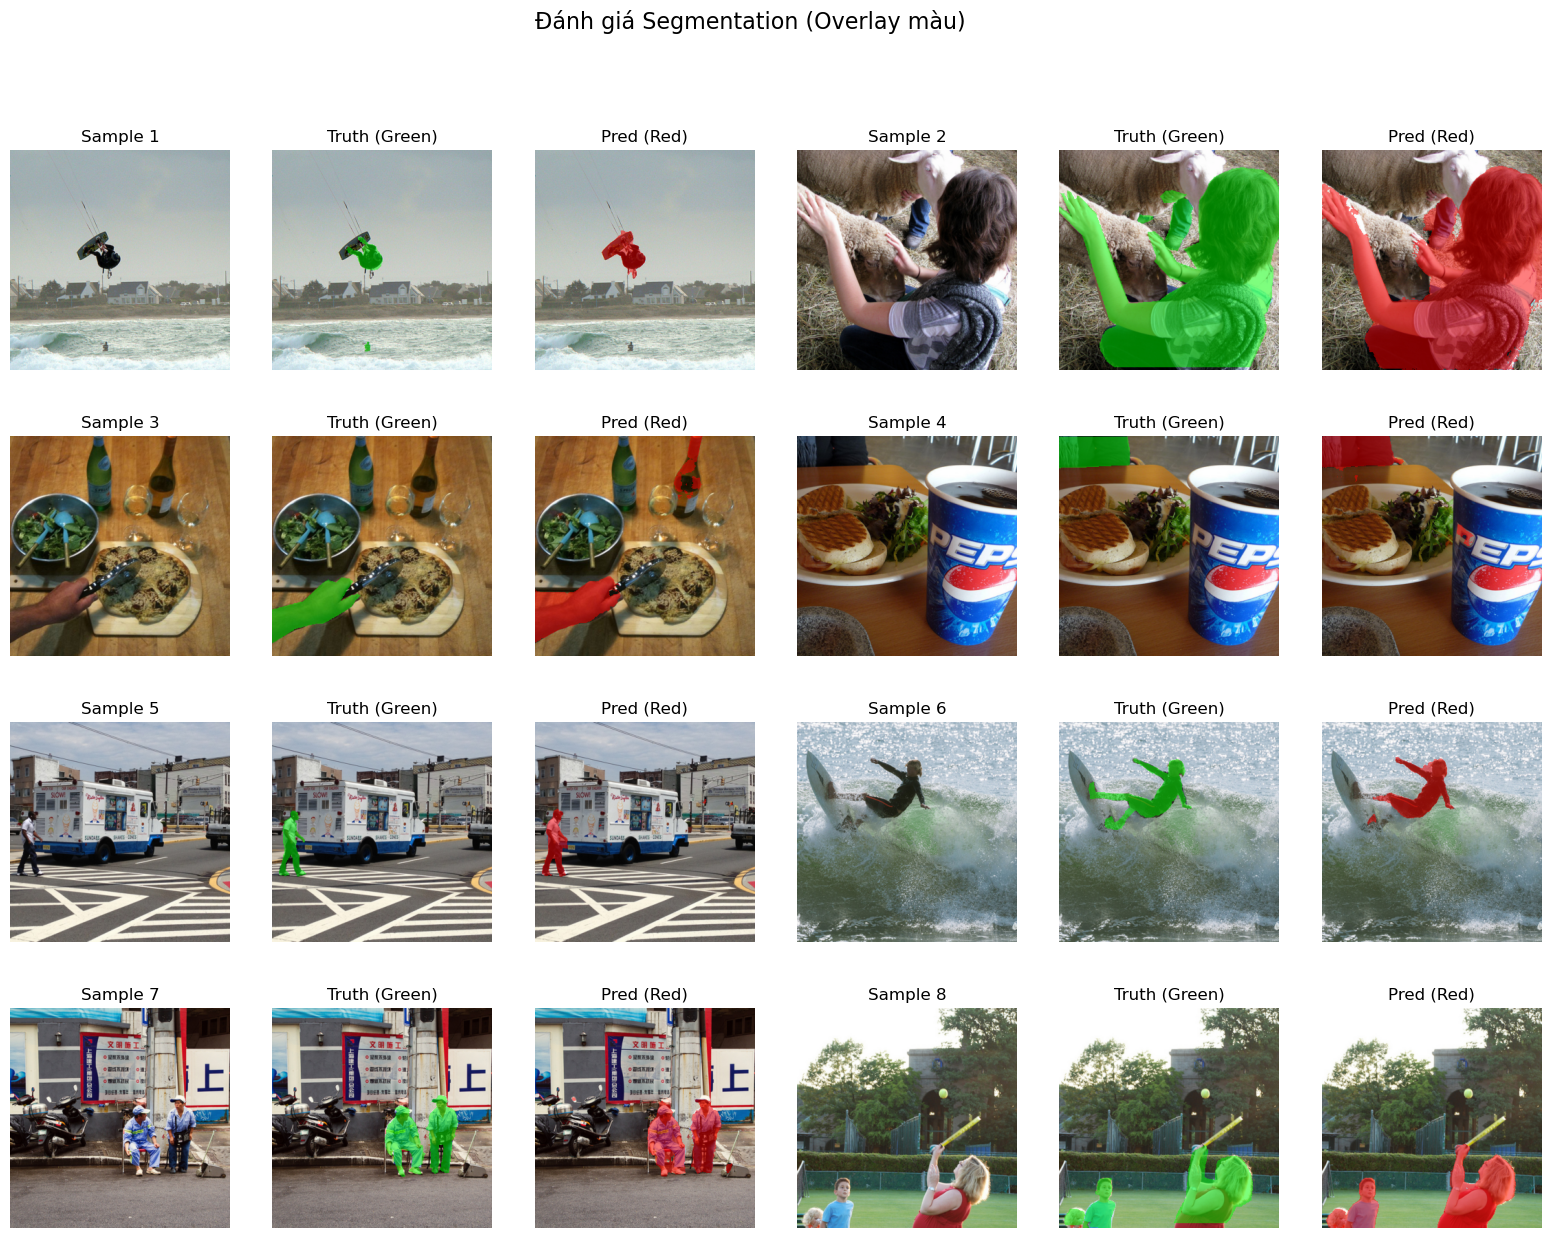

In [ ]:
viz.show_predictions(model, val_loader, cfg, num_samples=8, colored=True)

In [ ]:
!python run_tests.py

  UNet-Lite Test Suite

[tests.test_model]
  ✓ tests.test_model.TestUNetLite.test_build_model_from_config
  ✓ tests.test_model.TestUNetLite.test_count_parameters
  ✓ tests.test_model.TestUNetLite.test_different_features
  ✓ tests.test_model.TestUNetLite.test_forward_shape
  ✓ tests.test_model.TestUNetLite.test_gradient_flow
  ✓ tests.test_model.TestUNetLite.test_output_range_before_sigmoid
  ✓ tests.test_model.TestUNetLite.test_quant_stubs_present
  → 7 passed, 0 failed in 1.19s ✅

[tests.test_losses]
  ✓ tests.test_losses.TestBCEDiceLoss.test_output_positive
  ✓ tests.test_losses.TestBCEDiceLoss.test_perfect_prediction_low_loss
  ✓ tests.test_losses.TestBuildLoss.test_build_all_loss_names
  ✓ tests.test_losses.TestBuildLoss.test_invalid_loss_name
  ✓ tests.test_losses.TestFocalDiceLoss.test_focal_lower_than_bce
  ✓ tests.test_losses.TestOHEMDiceLoss.test_ohem_selects_hard_pixels
  ✓ tests.test_losses.TestOHEMDiceLoss.test_top_k_1_percent
  → 7 passed, 0 failed in 0.02s ✅

[tests.test_